In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

import random
import re
import math

from ast import literal_eval
from networkx.algorithms.community import louvain_communities
import matplotlib.colors as mcolors
from collections import Counter

random.seed(2)
np.random.seed(2)

# Assignment 2 - Group 2

Group members:
- Mathias (s214422)
- Nikolai (s224171)
- Sofie (s224185)

## Contributions
All three team members contributed across all sub parts of the project, but the main responsibles for different sections are as follows:
* Part 1 (Analyze the network): Nikolai (s224171)
* Part 2 (Genres and communities and plotting): Mathias (s214422)
* Part 3 (TF-IDF to understand genres and communities): Sofie (s224185)
* Part 4 (Sentiment of the artists and communities): Mathias (s214422)

All members have completed the weekly exercises needed for this project. The final result is a combination of different approaches, reflecting the work of individual efforts into the resulting outcome.

## Introduction to the network

In the following assignment, we'll analyze a network consisting of rock bands and performers. The network was built by crawling Wikipedia for the pages listed in [this article](https://en.wikipedia.org/wiki/List_of_mainstream_rock_performers). The final network has the different artists as its nodes. All the links in a given article, that leads to other Wikipedia articles in the list of mainstream rock performers, are represented as directed links in the network.

## Part 1: Analyze the network

In [2]:
RAW = "https://raw.githubusercontent.com/mathiaskrois/02805-Social-graphs-and-interactions---Fall-2025/main/data"

nodes_url = f"{RAW}/rock_nodes.csv"
edges_url = f"{RAW}/rock_edges.csv"
genres_url = f"{RAW}/artists_genres.csv"

nodes = pd.read_csv(nodes_url)
edges = pd.read_csv(edges_url)
genres = pd.read_csv(genres_url)

# Reconstruct the directed graph
G = nx.DiGraph()
G.add_nodes_from(nodes["node"])
nx.set_node_attributes(
    G, {row.node: int(row.content_length) for _, row in nodes.iterrows()},
    name="content_length"
)
G.add_edges_from(edges[["source","target"]].itertuples(index=False, name=None))

print("Loaded:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

Loaded: 485 nodes, 8074 edges


Firstly, to get a sense of the connectedness of the network, we took a look at the degree distribution of the network:

Average in-degree: 16.647422680412372
Average out-degree: 16.647422680412372
Average degree: 33.294845360824745


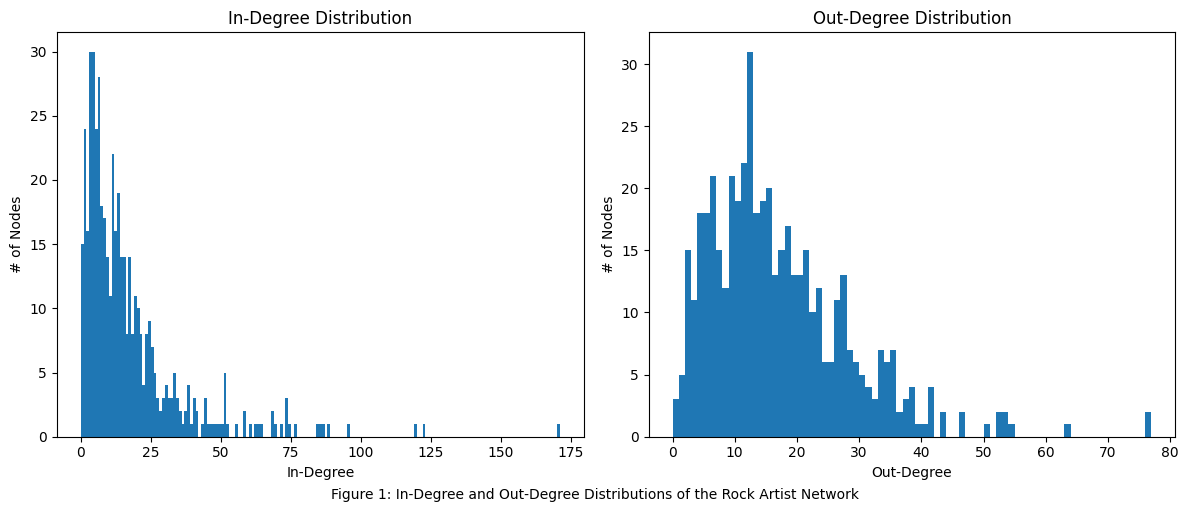

In [3]:
average_in_degree = sum(dict(G.in_degree()).values()) / G.number_of_nodes()
average_out_degree = sum(dict(G.out_degree()).values()) / G.number_of_nodes()
average_degree = average_in_degree + average_out_degree

print("Average in-degree:", average_in_degree)
print("Average out-degree:", average_out_degree)
print("Average degree:", average_degree)

v_in = np.array(range(np.min([d for n, d in G.in_degree()]), np.max([d for n, d in G.in_degree()])+1))
v_out = np.array(range(np.min([d for n, d in G.out_degree()]), np.max([d for n, d in G.out_degree()])+1))

in_deg_dist = np.histogram([d for n, d in G.in_degree()], bins=v_in)
out_deg_dist = np.histogram([d for n, d in G.out_degree()], bins=v_out)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(in_deg_dist[1][:-1], in_deg_dist[0], width=np.diff(in_deg_dist[1]), align='edge')
plt.title("In-Degree Distribution")
plt.xlabel("In-Degree")
plt.ylabel("# of Nodes")
plt.subplot(1, 2, 2)
plt.bar(out_deg_dist[1][:-1], out_deg_dist[0], width=np.diff(out_deg_dist[1]), align='edge')
plt.title("Out-Degree Distribution")
plt.xlabel("Out-Degree")
plt.ylabel("# of Nodes")
plt.figtext(0.5, 0, "Figure 1: In-Degree and Out-Degree Distributions of the Rock Artist Network", ha="center", va="center")
plt.tight_layout()
plt.show()

Rock artists are thus connected to 33 other rock artists on average. As is the case with many real networks (especially social networks), we also see examples of some outliers having significantly higher in or out degrees, compared to the average. These artists are likely very influential artists, and therefore are referenced and/or reference artists a lot. If we take a look at the top-5 nodes with the highest degrees:

In [4]:
sorted(G.degree(), key=lambda x: x[1], reverse=True)[:5]

[('The_Beatles', 200),
 ('The_Rolling_Stones', 156),
 ('Led_Zeppelin', 154),
 ('Queen_(band)', 141),
 ('Black_Sabbath', 137)]

we see that they *are* very well-known rock artists. If we plot a heatmap of the in-degree vs. the out-degree, we get an idea of how they're correlated:

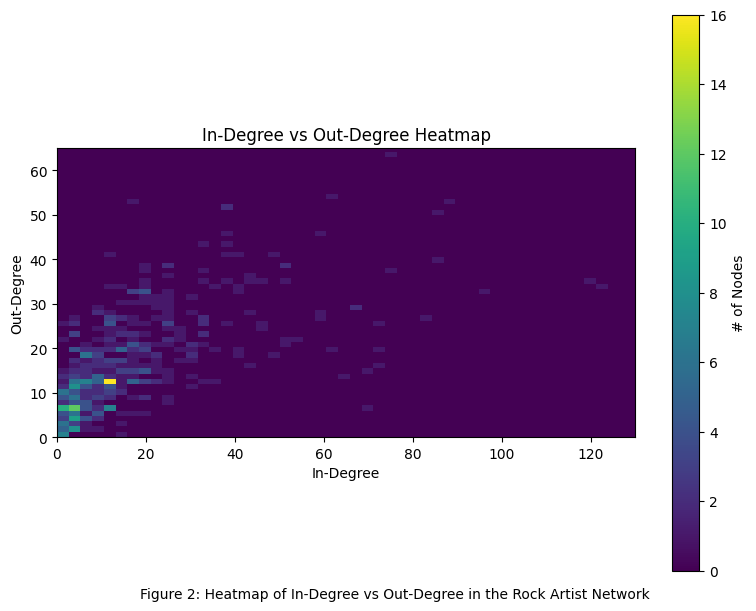

In [5]:
x = [G.in_degree(n) for n in G.nodes()]
y = [G.out_degree(n) for n in G.nodes()]

heatmap, xedges, yedges = np.histogram2d(x, y, bins=65)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.figure(figsize=(8, 6))
plt.imshow(heatmap.T, extent=extent, origin='lower')
plt.colorbar(label='# of Nodes')
plt.xlabel('In-Degree')
plt.ylabel('Out-Degree')
plt.xlim(0, 130)
plt.ylim(0, 65)
plt.title('In-Degree vs Out-Degree Heatmap')
plt.figtext(0.5, 0, "Figure 2: Heatmap of In-Degree vs Out-Degree in the Rock Artist Network", ha="center", va="center")
plt.tight_layout()
plt.show()

Their relation seems to evolve in a somewhat logarithmic fashion; starting from the origin, artists tend to have higher out-degree than in-degree, but the trend evens out, and actually reverses, as we increase the degree. This can probably be explained by the fact that smaller artists might have been influenced by many artists (hence a higher out-degree), but might not have influenced or worked with many others, that would then reference them. As the in-degree increases, and we get to bigger artists, we see that the split between in- and out-degree is more evenly divided, but when we get to really big artists, the out-degree doesn't quite keep up. This makes sense, since famous artists are likely to influence and work with a lot of other artists, but there is a limit to how many artists you would reasonably include in your Wikipedia article. These artists are also more likely to influence smaller artists not worth mentioning in their own article. 

Another interesting property to look at, is the *centrality* of the network, which can be measured in different ways. Centrality analyzes nodes and structures a network according to some criterion. The simplest centrality is the degree centrality, which simply centralizes nodes with high degree. For the rock artist network, the artists with the top 5 degree centralities are:

In [6]:
deg_cent = nx.degree_centrality(G)
deg_cent = {k: v for k, v in sorted(deg_cent.items(), key=lambda item: item[1])}
top5_deg_cent = sorted(deg_cent.items(), key=lambda kv: kv[1], reverse=True)[:5]
top5_deg_cent

[('The_Beatles', 0.4132231404958678),
 ('The_Rolling_Stones', 0.3223140495867769),
 ('Led_Zeppelin', 0.3181818181818182),
 ('Queen_(band)', 0.2913223140495868),
 ('Black_Sabbath', 0.2830578512396694)]

which correlates perfectly with the artists with the top 5 highest degrees, that we calculated earlier. Other more sofisticated measures are closeness, betweenness and eigenvector centrality, which centralizes nodes with the shortest paths to others, nodes that lie on the most shortest paths, and nodes that have the most neighbours with high degree, respectively. Looking at the top 5 nodes according to these centrality measures:

In [7]:
close_cent = nx.closeness_centrality(G)
close_cent = {k: v for k, v in sorted(close_cent.items(), key=lambda item: item[1])}
top5_close_cent = sorted(close_cent.items(), key=lambda kv: kv[1], reverse=True)[:5]
top5_close_cent

[('The_Beatles', 0.5982710826549715),
 ('The_Rolling_Stones', 0.5584329381323859),
 ('Led_Zeppelin', 0.5413574122778282),
 ('The_Who', 0.5287816316828786),
 ('Bob_Dylan', 0.5264521971820729)]

In [8]:
bet_cent = nx.betweenness_centrality(G)
bet_cent = {k: v for k, v in sorted(bet_cent.items(), key=lambda item: item[1])}
top5_bet_cent = sorted(bet_cent.items(), key=lambda kv: kv[1], reverse=True)[:5]
top5_bet_cent

[('Deep_Purple', 0.03998117704478117),
 ('Queen_(band)', 0.03820263081212352),
 ('The_Rolling_Stones', 0.036349951699155905),
 ('Alice_in_Chains', 0.033875453320835365),
 ("Guns_N'_Roses", 0.03324465388304094)]

In [9]:
G_rev = G.reverse(copy=False)
ec_in = nx.eigenvector_centrality(G_rev, max_iter=10_000, tol=1e-06)
top5_in = sorted(ec_in.items(), key=lambda kv: kv[1], reverse=True)[:5]
top5_in

[('Alice_in_Chains', 0.19877520346459),
 ('Deep_Purple', 0.1748631622483457),
 ('Black_Sabbath', 0.17047761936152592),
 ('Metallica', 0.15769618303625632),
 ('Megadeth', 0.14936352328811411)]

we see that the top 5 according to closeness are the same (except for The Who switching with Queen), but we get quite different results for the other two centrality measures. Artists with high betweenness are likely to have many connections, e.g., due to collaborations. Artists with high eigenvector centrality are have had influence on many artists with high in-degree, and therefore probably a big influence on rock in general. 

In the discussion of centrality, shortest paths were brought up. Analyzing the shortest paths in a network is - amongst other things - another way of figuring out the connectedness of a network. If the artist network contains very short paths between nodes, it means that all the artists are closely connected. Calculating the distribution of shortest paths in the network, we can compare it to a random network with the same number of nodes $N$ and probability of linking $p$:

Observed: 2.740  | Random: 2.006


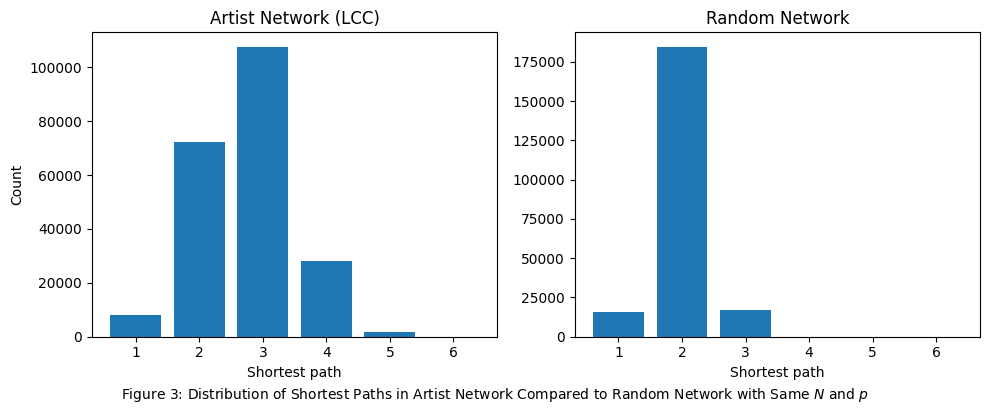

In [10]:
largest_cc = max(nx.strongly_connected_components(G), key=len)
DG_sub = G.subgraph(largest_cc).copy()

N = DG_sub.number_of_nodes()
E = DG_sub.number_of_edges()
p = 2*E/(N*(N-1))

G_rand = nx.erdos_renyi_graph(N,p,directed=True)
avg_obs  = nx.average_shortest_path_length(DG_sub)
avg_rand = nx.average_shortest_path_length(G_rand)
print(f"Observed: {avg_obs:.3f}  | Random: {avg_rand:.3f}")

def sp_length_counts(G):
    c = Counter()
    for _, dist in nx.all_pairs_shortest_path_length(G):
        for d in dist.values():
            if d > 0:
                c[d] += 1
    return c

cnt_obs  = sp_length_counts(DG_sub)
cnt_rand = sp_length_counts(G_rand)

max_len = max([0, *cnt_obs.keys(), *cnt_rand.keys()])
bins = np.arange(1, max_len + 2) - 0.5

vals_obs  = [cnt_obs.get(k, 0)  for k in range(1, max_len + 1)]
vals_rand = [cnt_rand.get(k, 0) for k in range(1, max_len + 1)]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(range(1, max_len+1), vals_obs)
plt.title("Artist Network (LCC)")
plt.xlabel("Shortest path")
plt.ylabel("Count")
plt.subplot(1,2,2)
plt.bar(range(1, max_len+1), vals_rand)
plt.title("Random Network")
plt.xlabel("Shortest path")
plt.figtext(0.5, 0, "Figure 3: Distribution of Shortest Paths in Artist Network Compared to Random Network with Same $N$ and $p$", ha="center", va="center")
plt.tight_layout()
plt.show()

As can be seen in Figure 3, the distribution of shortest paths has a higher mean and variance for the artist network compared to the random network. It *does*, however, still contain fairly short paths, as artists are under 3 hand shakes away from all other artists on average, i.e., half of the proposed *six degrees of separation* between random individuals - which makes sense.

The final property we'll look at in this part is *network assortativity*. Assortativity is a measure of how much nodes with a shared attribute tend to mix. A simple attribute to look at, is how nodes mix according to their in- and out-degree. For directed networks, 4 types of assortativity can be calculated, due to link directions:

In [11]:
print("Assortativity (in-in): ", np.round(nx.degree_assortativity_coefficient(G, x='in', y='in'), 5))
print("Assortativity (in-out): ", np.round(nx.degree_assortativity_coefficient(G, x='in', y='out'), 5))
print("Assortativity (out-in): ", np.round(nx.degree_assortativity_coefficient(G, x='out', y='in'), 5))
print("Assortativity (out-out): ", np.round(nx.degree_assortativity_coefficient(G, x='out', y='out'), 5))

Assortativity (in-in):  0.04489
Assortativity (in-out):  0.06117
Assortativity (out-in):  0.01623
Assortativity (out-out):  0.08802


All assortativities are fairly close to 0 (with the largest being nodes linking to other nodes with comparative out-degree), so the network is non-assortative, and there is no clear pattern in the way the rock artists are linked, at least in terms of how much they mention each other in their Wikipedia pages. Assortativity can also be measured wrt. other attributes - for the artist network, we've also saved the amount of words in each article. Calculating the assortativity wrt. that, we get:

In [13]:
nx.attribute_assortativity_coefficient(G, 'content_length', nodes=None)

-0.0027660014762676925

which is also very close to 0, meaning the network is also non-assortative in this regard.

Large networks can sometimes be quite messy to look at and analyze. A way of *filtering away the clutter* in networks, is by extracting the *network backbone*. The network backbone method essentially calculates which nodes are statistically significant for every node according to a threshold. The extracted backbone thus consists of the significant nodes for each node in the network, which can give a clearer view of structure in an otherwise messy network. Network backbones only work for weighted networks, and since the artist network is unweighted, we should have some way to assign meaningful weight to the links, for us to use the backbone method. In the following code block, we assign weight with three different methods,
- Weights are proportional to the betweenness of nodes
- Weights are proportional to 1/(Weights in the first method) 
- Weights are calculated with the [**High-Salience Skeleton**](https://www.nature.com/articles/ncomms1847) method
Using these methods three backbones are extracted and plotted:

B1 edges: 1471 of 6561
B2 edges: 1014 of 6561
B3 edges: 1094 of 6561


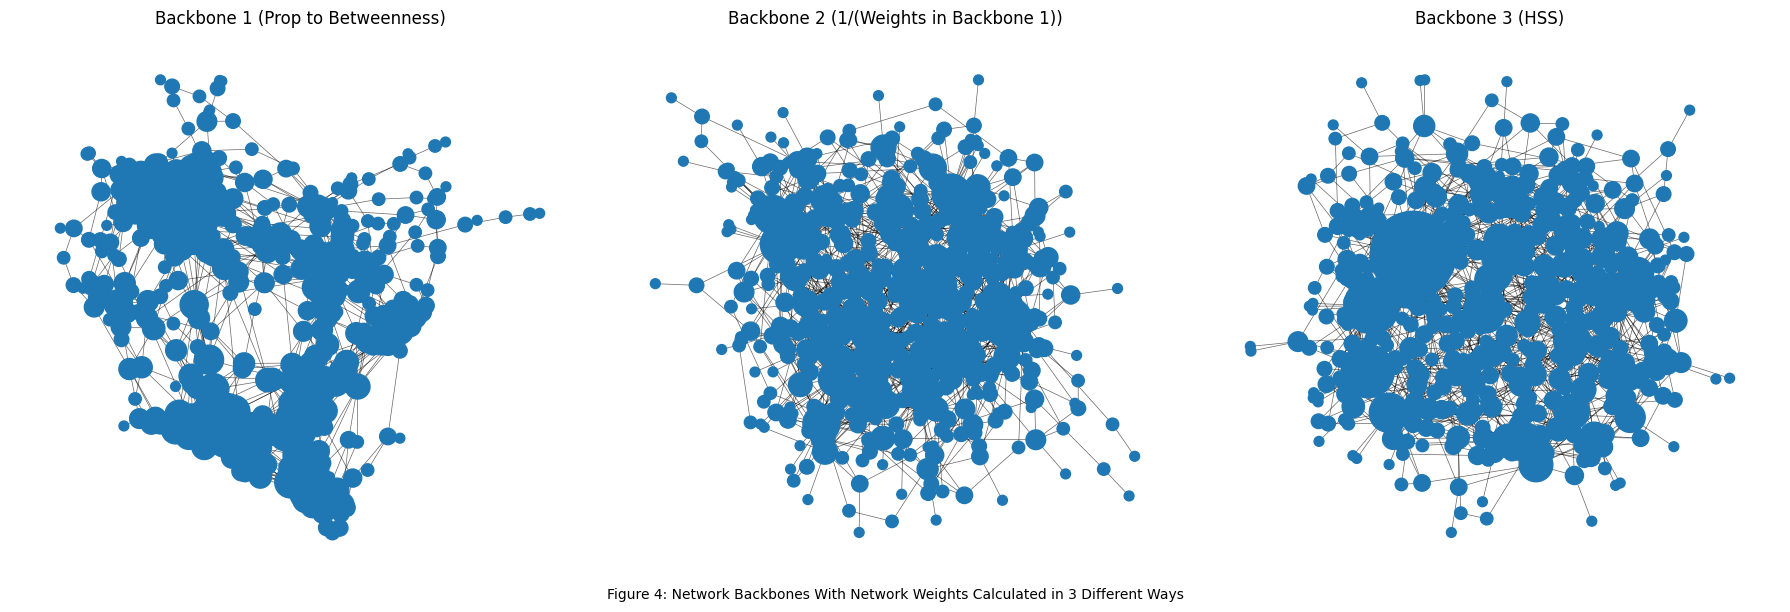

In [15]:
# ---- base: undirected giant connected component from DG ----
UG = G.to_undirected()
gcc_nodes = max(nx.connected_components(UG), key=len)
G_cc = UG.subgraph(gcc_nodes).copy()

# ---- Weighted Network 1: weights ∝ edge betweenness, rescaled to [1, 100] ----
eb = nx.edge_betweenness_centrality(G_cc, normalized=True)  # dict[(u,v)] -> betweenness
vals = np.fromiter(eb.values(), dtype=float)
vmin = float(vals.min())
vmax = float(vals.max())
if vmax == vmin:
    # all equal: assign weight 1
    w1 = {e: 1.0 for e in G_cc.edges()}
else:
    # linear map to [1, 100]
    w1 = {e: 1.0 + 99.0 * (eb[e] - vmin) / (vmax - vmin) for e in G_cc.edges()}
G_w1 = G_cc.copy()
nx.set_edge_attributes(G_w1, w1, name="weight")

# ---- Weighted Network 2: weights ∝ 1 / (weight in network 1) ----
w2 = {e: 1.0 / w1[e] if w1[e] > 0 else float("inf") for e in G_cc.edges()}
G_w2 = G_cc.copy()
nx.set_edge_attributes(G_w2, w2, name="weight")

# ---- Weighted Network 3: High-Salience Skeleton (salience via shortest-path trees) ----
# Self-contained implementation (sampling for speed). Set k=None to use all sources.
def high_salience_skeleton(G, k=200, threshold=0.5, weight="weight"):
    n = G.number_of_nodes()
    nodes = list(G.nodes())
    if k is None or k >= n:
        sources = nodes
    else:
        rng = np.random.default_rng(42)
        sources = list(rng.choice(nodes, size=k, replace=False))

    edge_hits = {tuple(sorted(e)): 0 for e in G.edges()}
    for s in sources:
        # predecessor lists for shortest-path DAG from s
        preds, _ = nx.dijkstra_predecessor_and_distance(G, s, weight=weight)
        for v, ps in preds.items():
            for p in ps:
                e = tuple(sorted((p, v)))
                if e in edge_hits:
                    edge_hits[e] += 1

    denom = float(len(sources)) if len(sources) > 0 else 1.0
    salience = {e: edge_hits[e] / denom for e in edge_hits}

    # backbone: keep edges with salience >= threshold
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    keep = [(u, v, {"salience": s}) for (u, v), s in salience.items() if s >= threshold]
    H.add_edges_from(keep)
    return H, salience

# build skeleton using unweighted shortest paths on G_cc; set k=None to use all sources
G_w3, sal = high_salience_skeleton(G_cc, k=200, threshold=0.5, weight=None)

def disparity_backbone(G, alpha=0.05, weight="weight", both_ends=True):
    if G.is_directed():
        raise ValueError("Use an undirected graph")
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))

    k = dict(G.degree())
    # node strengths
    s = {n: 0.0 for n in G.nodes()}
    for u, v, d in G.edges(data=True):
        w = float(d.get(weight, 1.0))
        s[u] += w; s[v] += w

    for u, v, d in G.edges(data=True):
        w = float(d.get(weight, 1.0))
        p_u = w / s[u] if s[u] > 0 else 0.0
        p_v = w / s[v] if s[v] > 0 else 0.0

        pv_u = 1.0 - (1.0 - p_u) ** max(k[u] - 1, 0)   # correct p-value
        pv_v = 1.0 - (1.0 - p_v) ** max(k[v] - 1, 0)

        sig_u = (k[u] == 1) or (pv_u < alpha)
        sig_v = (k[v] == 1) or (pv_v < alpha)

        keep = (sig_u and sig_v) if both_ends else (sig_u or sig_v)
        if keep:
            H.add_edge(u, v, **{weight: w, "p_u": p_u, "p_v": p_v,
                                "pv_u": pv_u, "pv_v": pv_v})
    return H

alpha = 0.5
B1 = disparity_backbone(G_w1, alpha=alpha, weight="weight", both_ends=True)
B2 = disparity_backbone(G_w2, alpha=alpha, weight="weight", both_ends=True)

print(f"B1 edges: {B1.number_of_edges()} of {G_w1.number_of_edges()}")
print(f"B2 edges: {B2.number_of_edges()} of {G_w2.number_of_edges()}")


def high_salience_skeleton(G, k=None, threshold=0.5, weight="weight", seed=42):
    """
    Approximate HSS on an undirected weighted graph using Dijkstra trees from k sources.
    Set k=None to use all nodes as sources.
    """
    if G.is_directed():
        raise ValueError("Use an undirected graph")
    nodes = list(G.nodes())
    if k is None or k >= len(nodes):
        sources = nodes
    else:
        rng = np.random.default_rng(seed)
        sources = list(rng.choice(nodes, size=k, replace=False))

    # count how often an edge appears in shortest-path trees
    hits = {tuple(sorted(e)): 0 for e in G.edges()}
    for s in sources:
        preds, _ = nx.dijkstra_predecessor_and_distance(G, s, weight=weight)
        for v, ps in preds.items():
            for p in ps:
                e = tuple(sorted((p, v)))
                if e in hits:
                    hits[e] += 1

    denom = float(len(sources)) if sources else 1.0
    salience = {e: hits[e] / denom for e in hits}

    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    for (u, v), s in salience.items():
        if s >= threshold:
            H.add_edge(u, v, salience=s)
    return H, salience

# Weighted Network 3 backbone via HSS
B3, sal = high_salience_skeleton(G_cc, k=200, threshold=0.5, weight="weight")
print(f"B3 edges: {B3.number_of_edges()} of {G_cc.number_of_edges()}")

def lcc(G):
    comps = list(nx.connected_components(G))
    if not comps:
        return G.copy()
    S = max(comps, key=len)
    return G.subgraph(S).copy()

def plot_fa2(G, title, ax):
    H = lcc(G)
    deg = dict(H.degree())
    node_sizes = [deg[n] * 30 + 20 for n in H.nodes()]
    pos = nx.forceatlas2_layout(H)  # your working version
    nx.draw_networkx_edges(H, pos, ax=ax, width=0.5, alpha=0.6)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_size=node_sizes)
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_fa2(B1, "Backbone 1 (Prop to Betweenness)", axes[0])
plot_fa2(B2, "Backbone 2 (1/(Weights in Backbone 1))", axes[1])
plot_fa2(B3, "Backbone 3 (HSS)", axes[2])
plt.figtext(0.5, 0, "Figure 4: Network Backbones With Network Weights Calculated in 3 Different Ways", ha="center", va="center")
plt.tight_layout()
plt.show()

All the methods lead to the extraction of different backbones. The most interesting one comes from the first method, as it highlights *communities* in the network, which we'll dive into in the next part.

## Part 2: Genres and communities and plotting

Average number of genres per band: 3.89
Number of bands with genres: 464
Total number of distinct genres: 208


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, 'alternative rock'),
  Text(1, 0, 'hard rock'),
  Text(2, 0, 'pop rock'),
  Text(3, 0, 'rock'),
  Text(4, 0, 'alternative metal'),
  Text(5, 0, 'heavy metal'),
  Text(6, 0, 'blues rock'),
  Text(7, 0, 'pop'),
  Text(8, 0, 'post-grunge'),
  Text(9, 0, 'soft rock'),
  Text(10, 0, 'indie rock'),
  Text(11, 0, 'new wave'),
  Text(12, 0, 'art rock'),
  Text(13, 0, 'progressive rock'),
  Text(14, 0, 'folk rock')])

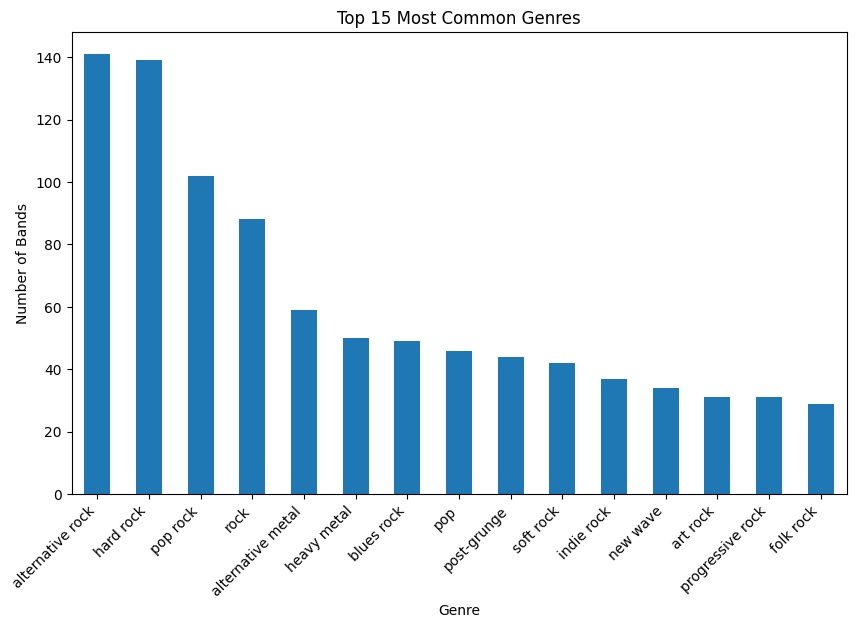

In [16]:
RAW = "https://raw.githubusercontent.com/mathiaskrois/02805-Social-graphs-and-interactions---Fall-2025/main/data"

nodes_url = f"{RAW}/rock_nodes.csv"
edges_url = f"{RAW}/rock_edges.csv"
genres_url = f"{RAW}/artists_genres.csv"

nodes = pd.read_csv(nodes_url)
edges = pd.read_csv(edges_url)
genres = pd.read_csv(genres_url)



def normalize_spaces(s: str) -> str:
    
    s = s.replace("\xa0", " ")
    s = re.sub(r"&\s*nbsp;?", " ", s, flags=re.I)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

def unify_variants(g: str) -> str:
    g = g.lower().strip(" '\"")             
    g = g.replace("’", "'")
    g = re.sub(r"rock\s*(?:'n'|’n’|n|&)\s*roll", "rock and roll", g)
    g = re.sub(r"\s*,\s*", ",", g)         
    g = re.sub(r"\s{2,}", " ", g)
    return g

def parse_genres(cell) -> list[str]:
    if pd.isna(cell):
        return []
    s = str(cell).strip()
    s = normalize_spaces(s)

    # If it looks like a Python list string, parse it safely
    if s.startswith("[") and s.endswith("]"):
        try:
            parsed = literal_eval(s)
            parts = [str(p) for p in parsed]
        except Exception:
            parts = s.strip("[]").split(",")
    else:
        parts = s.split(",")

    cleaned = []
    for p in parts:
        p = normalize_spaces(str(p))
        p = p.strip("[](){} '\"")          
        p = unify_variants(p)
        # collapse artifacts like "nu  metal" that came from "&nbsp;"
        p = re.sub(r"\s{2,}", " ", p).strip()
        if p and p.lower() != "nan" and p.lower() != "nbsp" and p != "&":
            cleaned.append(p)
    return cleaned

df = genres

df["genres"] = df["genres"].apply(parse_genres)
df["num_genres"] = df["genres"].apply(len)

avg_per_band = df["num_genres"].mean()
bands_with_genres = (df["num_genres"] > 0).sum()

all_genres = [g for lst in df["genres"] for g in lst]
genre_counts = pd.Series(all_genres, dtype="string").value_counts()
total_distinct = len(genre_counts)

print(f"Average number of genres per band: {avg_per_band:.2f}")
print(f"Number of bands with genres: {bands_with_genres}")
print(f"Total number of distinct genres: {total_distinct}")

top15 = genre_counts.head(15)

plt.figure(figsize=(10, 6))
top15.plot(kind="bar")
plt.title("Top 15 Most Common Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Bands")
plt.xticks(rotation=45, ha="right")

In the code above, you can see the average number of genres per band, number of bands with genres ant the total number of distinct genres, as well as a plot of the most popular genres. As is evident from the plot, different sub genres of rock are highly represented in the graph, which makes sense, as it comes from a list of rock bands and perfromers.

In the code bellow, we will start looking at the genres and communites you can find in the network.

In [17]:
def canon_name(s: str) -> str:
    s = str(s)
    s = s.replace("\xa0", " ")
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

def clean_genre_list(cell):
    if pd.isna(cell):
        return []
    parts = [re.sub(r"\s+", " ", g).strip().lower() 
             for g in str(cell).replace("\xa0"," ").split(",")]
    return [g for g in parts if g and g != "nan" and g != "nbsp"]

def modularity(G: nx.Graph, labels: dict[str, str]) -> float:
    m = G.number_of_edges()
    if m == 0:
        return float("nan")
    deg = dict(G.degree())
    M = 0.0
    for u, v in G.edges():
        cu = labels.get(u)
        cv = labels.get(v)
        if cu is None or cv is None:
            continue
        if cu == cv:
            M += 1 - (deg[u] * deg[v]) / (2*m)
    return M / (2*m)

# load your data 
edges = pd.read_csv(edges_url)
bands = pd.read_csv(genres_url)

# Canonical keys for matching between files
edges["u"] = edges.iloc[:,0].apply(canon_name)     
edges["v"] = edges.iloc[:,1].apply(canon_name)   
bands["key"] = bands["artist"].apply(canon_name)
bands["genres"] = bands["genres"].apply(clean_genre_list)

# Build undirected graph
G = nx.from_pandas_edgelist(edges, "u", "v", create_using=nx.Graph())

have_genre = set(bands.loc[bands["genres"].str.len() > 0, "key"])
H = G.subgraph(have_genre).copy()

print(f"After filtering: |V|={H.number_of_nodes()}, |E|={H.number_of_edges()}")

if H.number_of_edges() == 0:
    raise ValueError(
        "The filtered graph has 0 edges. "
        "Double-check that artist names in the edge list match those in bands.csv "
        "(case/spacing/punctuation). Try inspecting a few canonical names to debug."
    )

# First-genre labeling
first_genre_map = dict(
    bands[bands["key"].isin(H.nodes())][["key","genres"]]
    .apply(lambda r: (r["key"], r["genres"][0] if r["genres"] else None), axis=1)
)

M_first = modularity(H, first_genre_map)
print(f"Modularity (first genre): {M_first:.4f}" if pd.notna(M_first) else "Modularity (first genre): NaN")

# Random-genre labeling 
rng_map = {}
rows = bands[bands["key"].isin(H.nodes())]
for _, r in rows.iterrows():
    rng_map[r["key"]] = random.choice(r["genres"]) if r["genres"] else None

M_rand = modularity(H, rng_map)
print(f"Modularity (random genre per artist): {M_rand:.4f}" if pd.notna(M_rand) else "Modularity (random): NaN")

After filtering: |V|=108, |E|=630
Modularity (first genre): 0.0000
Modularity (random genre per artist): 0.0241


In [18]:
rows = bands[bands["key"].isin(H.nodes())][["key","genres"]]

def labels_first(row):  # baseline already used
    return row["genres"][0] if row["genres"] else None

def labels_random_multi(rows, seed=0):
    rnd = random.Random(seed)
    mapping = {}
    for _, r in rows.iterrows():
        gs = r["genres"]
        if not gs:
            mapping[r["key"]] = None
        elif len(gs) == 1:
            mapping[r["key"]] = gs[0]     
        else:
            mapping[r["key"]] = rnd.choice(gs)
    return mapping

first_map = dict(rows.assign(lbl=rows.apply(labels_first, axis=1))[["key","lbl"]].values)
rand_multi_map = labels_random_multi(rows, seed=42)

M_first = modularity(H, first_map)
M_rand_multi = modularity(H, rand_multi_map)
print(f"Modularity (first): {M_first:.4f}")
print(f"Modularity (rand only multi-genre): {M_rand_multi:.4f}")

Modularity (first): 0.0775
Modularity (rand only multi-genre): 0.0315


From the code you can see that the modularity using the first genre is 0.0775
A modularity value of 0.0775 is small but above zero. This is indicating that there is some tendency for artists sharing the same first genre to be connected to one another more than expected by chance.
This shows that genre does carry some structural information about the network. Artists of similar genres are somewhat clustered together. Hoever, it is not a strong signal. Modularity values above 0.3 are typical for networks with well-defined communities.
So genres explain only a minor fraction of the actual structure.

We will now try using the Louvain algorithm to find communities.

In [19]:
# Detect communities (Louvain)
louvain_comms = louvain_communities(H, seed=42, resolution=1.2)

louvain_labels = {node: i for i, comm in enumerate(louvain_comms) for node in comm}

# Compute modularity for these detected communities
def modularity_from_partition(G, partition):
    m = G.number_of_edges()
    if m == 0:
        return float('nan')
    deg = dict(G.degree())
    M = 0
    for i, j in G.edges():
        same = 1 if partition[i] == partition[j] else 0
        M += (1 - (deg[i] * deg[j]) / (2*m)) * same
    return M / (2*m)

M_detected = modularity_from_partition(H, louvain_labels)
print(f"Louvain modularity: {M_detected:.4f}")
print(f"Genre modularity (best rule): {M_first:.4f}")

Louvain modularity: 0.2400
Genre modularity (best rule): 0.0775


### Discussion 
The Louvain communities 0.2246 reveal a significantly stronger modular structure than the genre based division 0.078.
This suggests that while genre contributes weakly to how artists cluster and with thus that genre labels alone cannot fully capture the complex interconnections.

We will now look at the confusion matrix between the top genres and the found top communities.

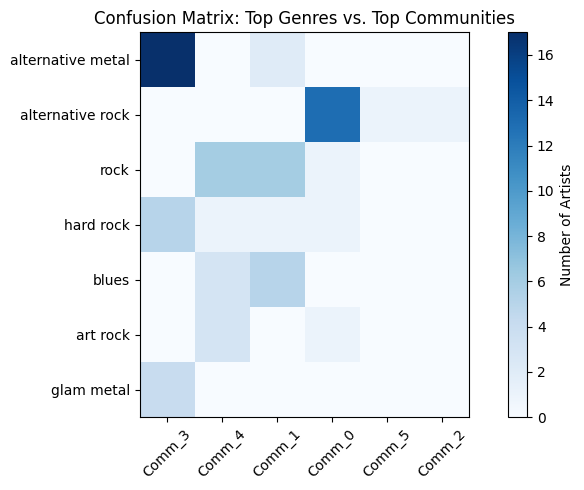

In [20]:
genre_map = {r["key"]: (r["genres"][0] if r["genres"] else None)
             for _, r in bands.iterrows() if r["key"] in H.nodes()}

genre_counts = pd.Series(list(genre_map.values())).value_counts()
top_genres = list(genre_counts.head(7).index)

comm_sizes = [len(c) for c in louvain_comms]
top_com_idx = np.argsort(comm_sizes)[::-1][:7]
top_comms = [i for i in top_com_idx]

D = pd.DataFrame(0, index=top_genres, columns=[f"Comm_{j}" for j in top_comms])

for node, comm_id in louvain_labels.items():
    g = genre_map.get(node)
    if g in top_genres and comm_id in top_comms:
        D.loc[g, f"Comm_{comm_id}"] += 1


#visualize 
plt.figure(figsize=(8, 5))
plt.imshow(D, cmap="Blues")
plt.xticks(ticks=range(len(D.columns)), labels=D.columns, rotation=45)
plt.yticks(ticks=range(len(D.index)), labels=D.index)
plt.title("Confusion Matrix: Top Genres vs. Top Communities")
plt.colorbar(label="Number of Artists")
plt.tight_layout()
plt.show()

Here it is again clear that different rock genres dominate the first communities, however it is other features that connect Community 4 and 2 respectively, as they do not belong in the top categories.

Below is a plot of the network divided into the communites

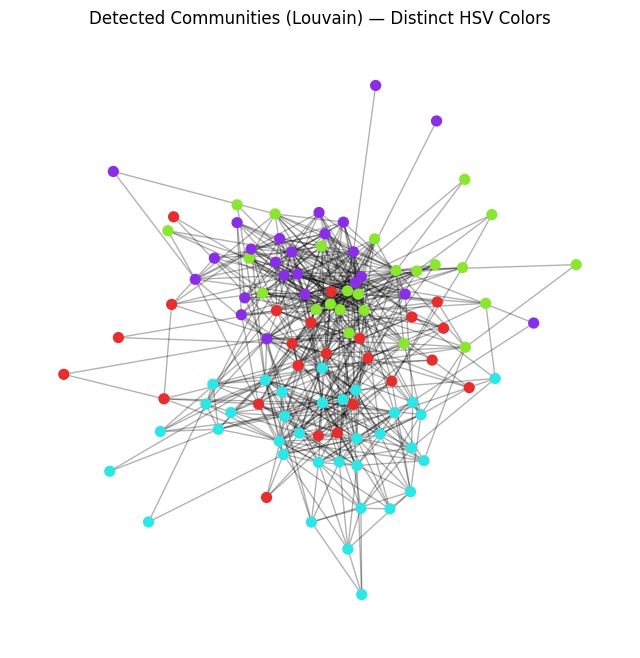

In [21]:
# Remove isolated nodes
H_connected = H.subgraph([n for n in H.nodes() if H.degree(n) > 0]).copy()

comm_ids = sorted(set(louvain_labels[n] for n in H_connected.nodes()))
n_comms = len(comm_ids)

# Generate distinct colors evenly across the HSV color wheel
colors_palette = [mcolors.hsv_to_rgb((i / n_comms, 0.8, 0.9)) for i in range(n_comms)]
colors = [colors_palette[comm_ids.index(louvain_labels[n])] for n in H_connected.nodes()]

# Plot
pos = nx.spring_layout(H_connected, seed=42)
plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(H_connected, pos, node_color=colors, node_size=50)
nx.draw_networkx_edges(H_connected, pos, alpha=0.3)
plt.title("Detected Communities (Louvain) — Distinct HSV Colors")
plt.axis("off")
plt.show()

### Discussion 
A Louvain community plot shows a network with several clearly defined clusters of artists. This visual structure supports the modularity result ≈0.28 indicating that the network has a moderate community organization. While distinct communities exist, the presence of interconnecting edges suggests overlap between musical styles—artists often bridge multiple genres rather than belonging to isolated groups.

## Part 3: TF-IDF to understand genres and communities 

The questions below  are based on Lecture 7, part 2, 4, 5, 6 (and a little bit on part 3).

* Explain the concept of TF-IDF in your own words and how it can help you understand the genres and communities.
* Calculate and visualize TF-IDF for the genres and communities.
* Use the matrix $D$ (Lecture 7, part 2) to dicusss the difference between the word-clouds between genres and communities.

TF-IDF is a way to look at the importance of words in a single document, by comparing it to other documents, where a single document can be made up of several texts within a certain subject. It concists of two parts *term frequency* and *inverse document frequency*. 

Term frequecy is used to count how many times a word is present in the current document. There are several ways to count this - one is the raw count, where you simply count how many times a word is present in a single text. Another is the augmented frequency, where you divide the raw frequency of a word with the raw frequency of the most frequently occuring term in the document, using the following formula:
$$tf(t,d)=0.5+0.5\cdot \frac{f_{t,d}}{max{f_{t',d}:t'\in d}}$$
where $f_{t,d}$ is the raw count “tf–idf (term frequency–inverse document frequency, TF*IDF)” — Wikipedia. Retrieved from https://en.wikipedia.org/wiki/Tf%E2%80%93idf. This is done, so words from longer documents aren't weighted higher than words from shorter document.There are more, that might apply better to other exercises.

Inverse document frequency is used as a weight, by looking at how common or rare it is. It is found by dividing the total number of documents by the amount of documents the word is present in, and taking the log of this number. There are a few ways to find the fraction, but the common part is using log, which can be chosen to have different bases.

Using this means it isn't as necessary to remove stop words, as those will likeley be pressent in most, if not all, of the documents, and will therefore be weighted very low - 0 if they are present in all the documents.

By applying this to the wiki-texts split into the genres the artists belong to, it becomes possible to look more at what words are dominant within a specific genre or community. By doing this, it will will also be clearer to see which genre a community might be centered around. 

In the code bellow TF-IDF will be calculated and visualized for both genres and communities.

In [ ]:
# Step 1: Import libraries
import networkx as nx
import pickle
import os
from collections import Counter
import math
from nltk.probability import FreqDist
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
import re
import pandas as pd
import requests
import nltk
from nltk.tokenize import RegexpTokenizer
import networkx.algorithms.community as nx_comm
import math
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK data if needed
# nltk.download('punkt', quiet=True)

In [ ]:
RAW = "https://raw.githubusercontent.com/mathiaskrois/02805-Social-graphs-and-interactions---Fall-2025/main/data"

nodes_url = f"{RAW}/rock_nodes.csv"
edges_url = f"{RAW}/rock_edges.csv"
genres_url = f"{RAW}/artists_genres.csv"

nodes = pd.read_csv(nodes_url)
edges = pd.read_csv(edges_url)
genres = pd.read_csv(genres_url)

def canon_name(s: str) -> str:
    s = str(s)
    s = s.replace("\xa0", " ")
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

def clean_genre_list(cell):
    if pd.isna(cell):
        return []
    parts = [re.sub(r"\s+", " ", g).strip().lower() 
             for g in str(cell).replace("\xa0"," ").split(",")]
    return [g for g in parts if g and g != "nan" and g != "nbsp"]

# Canonical keys for matching between files
edges["u"] = edges.iloc[:,0].apply(canon_name)
edges["v"] = edges.iloc[:,1].apply(canon_name)
bands = genres.copy()
bands["key"] = bands["artist"].apply(canon_name)
bands["genres"] = bands["genres"].apply(clean_genre_list)

# Build undirected graph
G = nx.from_pandas_edgelist(edges, "u", "v", create_using=nx.Graph())

have_genre = set(bands.loc[bands["genres"].str.len() > 0, "key"])
H = G.subgraph(have_genre).copy()

In [ ]:
# Compute modularity for these detected communities
def modularity_from_partition(G, partition):
    m = G.number_of_edges()
    if m == 0:
        return float('nan')
    deg = dict(G.degree())
    M = 0
    for i, j in G.edges():
        same = 1 if partition[i] == partition[j] else 0
        M += (1 - (deg[i] * deg[j]) / (2*m)) * same
    return M / (2*m)

In [ ]:
# API endpoint to list files in the folder
api_url = (
    "https://api.github.com/repos/"
    "mathiaskrois/02805-Social-graphs-and-interactions---Fall-2025"
    "/contents/data/wikitext_pages"
)

# If repo/folder is private, set token here, e.g. headers = {'Authorization': 'token <TOKEN>'}
headers = {}

# If 'files' already exists from earlier, reuse it; otherwise fetch from GitHub API
try:
    files  # noqa: F821
except NameError:
    r = requests.get(api_url, headers=headers)
    r.raise_for_status()
    files = r.json()

# Genre normalization map
CANON_MAP = {
    # punctuation/spacing variants
    "rock & roll": "rock and roll",
    "rock 'n' roll": "rock and roll",
    "rock'n'roll": "rock and roll",
    "rock 'n' roll": "rock and roll",
    "rock'n'roll": "rock and roll",
    "rock n roll": "rock and roll",
    "new-wave": "new wave",
    "post punk": "post-punk",
    "post punk revival": "post-punk revival",
    "alt-country": "alternative country",
    "alt country": "alternative country",
    "alt pop": "alternative pop",
    "alt-pop": "alternative pop",
    "alt rock": "alternative rock",
    "alt. rock": "alternative rock",
    "electronic-rock": "electronic rock",
    "folk-rock": "folk rock",
    "indie-pop": "indie pop",
    "indie-rock": "indie rock",
    "jazz-rock": "jazz rock",
    "noise-rock": "noise rock",
    "pop-punk": "pop punk",
    "post-grunge": "post-grunge",
    "power-pop": "power pop",
    "synth-pop": "synthpop",
    "synth pop": "synthpop",
    # abbrevs
    "r&b": "rhythm and blues",
    "randb": "rhythm and blues",
    "new orleans randb": "rhythm and blues",
    "hiphop": "hip hop",
    "hip-hop": "hip hop",
    "rap": "hip hop",
    # trailing qualifiers
    "blues rock (early)": "blues rock",
    "bubblegum (early)": "bubblegum",
    "country rock (early)": "country rock",
    "dance-rock (early)": "dance-rock",
    "death metal (early)": "death metal",
    "emo (early)": "emo",
    "folk rock (early)": "folk rock",
    "funk metal (early)": "funk metal",
    "garage rock revival": "garage rock",
    "glam metal (early)": "glam metal",
    "grunge (early)": "grunge",
    "hardcore punk (early)": "hardcore punk",
    "heavy metal (early)": "heavy metal",
    "indie pop (early)": "indie pop",
    "jazz rock (early)": "jazz rock",
    "lo-fi (early)": "lo-fi",
    "metalcore (early)": "metalcore",
    "neo-psychedelia": "neo-psychedelia",
    "new wave (early)": "new wave",
    "new wave (later)": "new wave",
    "no wave (early)": "no wave",
    "nu metal (early)": "nu metal",
    "paisley underground": "paisley underground",
    "pop rock (early)": "pop rock",
    "post-punk (early)": "post-punk",
    "post-punk revival": "post-punk revival",
    "progressive rock (early)": "progressive rock",
    "progressive soul": "progressive soul",
    "psychedelia (early)": "psychedelia",
    "psychedelic folk (early)": "psychedelic folk",
    "psychedelic pop (early)": "psychedelic pop",
    "punk rock (early)": "punk rock",
    "shoegaze (early)": "shoegaze",
    # minor typos
    "acid rockeinarson": "acid rock",
    "noise rockanderson": "noise rock",
    "psychedelic rockdebolt": "psychedelic rock",
    "speed metalphillips": "speed metal",
    "thrash metalphillips": "thrash metal",
    "heavy metalphillips": "heavy metal",
}

# Updated clean_genre function with better filtering
def clean_genre(genre):
    """Clean and normalize a single genre string"""
    # Basic cleaning
    genre = genre.replace('&nbsp;', ' ').strip().lower()
    
    # Remove (early), (later), etc.
    genre = re.sub(r'\s*\([^)]*\)', '', genre).strip()
    
    # Remove anything after a pipe (Wikipedia link descriptions)
    if '|' in genre:
        genre = genre.split('|')[0].strip()
    
    # Filter out non-genre terms
    BANNED_WORDS = {
        'music', 'musicians', 'band', 'bands', 'artists', 'artist', 'list of',
        'category', 'template', 'file', 'image', 'wikipedia', 'portal',
        'instruments', 'vocals', 'guitar', 'bass', 'drums', 'keyboard',
        'discography', 'albums', 'songs', 'singles', 'awards',
        'record label', 'label', 'labels', 'records',
        'hlist', 'flatlist', 'plainlist', 'unbulleted list', 'ubl',
        'small', 'nowrap', 'abbr', 'class', 'style',
        'reflist', 'ref', 'cite', 'citation', 'notable',
        'see also', 'main article', 'main',
        'united states', 'united kingdom', 'england', 'america', 'american',
        'british', 'canadian', 'australian', 'european',
        'http', 'www', 'com', 'org', 'net',
    }
    
    # Check if genre contains any banned words
    genre_words = set(genre.split())
    if genre_words & BANNED_WORDS:
        return None
    
    # Filter out if it looks like a template or markup
    if any(char in genre for char in ['{', '}', '<', '>', '=', '[', ']']):
        return None
    
     # Apply canonical mapping
    if genre in CANON_MAP:
        return CANON_MAP[genre]
    
    return genre

artist_texts = {}
artist_genres = {}
all_genres = set()

for item in files:
    # Skip subdirectories; keep only files
    if item.get('type') != 'file':
        continue
    name = item.get('name').lower()
    download_url = item.get('download_url')
    if not download_url:
        print('No download URL for', name)
        continue
    # print('Fetching', name)
    r = requests.get(download_url, headers=headers)
    if r.status_code == 403:
        print('HTTP 403: possible rate-limit or permission issue. Add an auth token to `headers`.')
        break
    r.raise_for_status()
    text = r.text
    test = text.lower()
    artist_texts[name.replace('.txt', '')] = text

    genre_found = False
    genres = []

    for word in text.split():
        if word == "genre" or word == "|genre":
            genre_found = True
            continue
        if genre_found:
            if word == "|" or word == "|discography"or word == "}}":
                break
            genres.append(word)
    
    genres = " ".join(genres)
     # Clean out reference tags
    genres = re.sub(r'<ref[^>]*>.*?</ref>', '', genres, flags=re.DOTALL)  # Remove <ref>...</ref>
    genres = re.sub(r'<ref[^>]*/', '', genres)  # Remove <ref ... />
    
    # Extract genres from [[...]]
    genre_match = re.findall(r'\[\[([^\]]+)\]\]', genres)

    genres_cleaned = []
    for g in genre_match:
        cleaned = clean_genre(g)
        if cleaned and cleaned not in genres_cleaned:  # Filter out None and duplicates
            genres_cleaned.append(cleaned)
            all_genres.add(cleaned)

    # Only add artist if they have genres
    if genres_cleaned:
        artist_genres[name.replace('.txt', '')] = genres_cleaned

# Extract artist names
artist_names = [name.replace('.txt', '').lower() for name in artist_texts.keys()]

In [ ]:
# Step 5: Tokenize artist texts
tokenizer = RegexpTokenizer(r'\w+')

# Banned tokens (formatting artifacts)
ban = {'{','}','|','=',':','[',']','(',')','-','.',',',';','!','?','&','<','>','/','\\','*','@','#','$','%','^','~','`',"''",'``',
       'com','cite','web','title','url','https','ref','www','website','access','http','s'}

artist_tokens = {}
for artist in artist_names:
    if artist in artist_texts:
        text = artist_texts[artist].lower()
        toks = tokenizer.tokenize(text)
        toks = [t for t in toks if t not in ban and len(t) > 2 and not t.isdigit()]
        artist_tokens[artist] = toks


In [ ]:
# Step 6: Count how many artists have each genre
all_genre_counts = Counter()
for artist, genres in artist_genres.items():
    for genre in genres:
        all_genre_counts[genre] += 1

# Get the top N largest genres by artist count
top_n_genres = 15
largest_genres = [genre for genre, count in all_genre_counts.most_common(top_n_genres)]


In [ ]:
# Step 7: Create genre-to-nodes mapping
largest_genre_to_nodes = {}
for genre in largest_genres:
    largest_genre_to_nodes[genre] = []
    for artist, genres in artist_genres.items():
        if genre in genres:
            largest_genre_to_nodes[genre].append(artist)

In [ ]:
# Step 8: Aggregate tokens for each genre
min_count = 5  # Minimum frequency threshold

largest_genre_token_list = {genre: [] for genre in largest_genres}

for genre, nodes in largest_genre_to_nodes.items():
    for node in nodes:
        if node in artist_tokens:
            largest_genre_token_list[genre].extend(artist_tokens[node])

# Calculate TF
largest_genre_tf = {}
for genre, toks in largest_genre_token_list.items():
    fd = FreqDist(toks)
    kept = [w for w, c in fd.items() if c >= min_count]
    largest_genre_tf[genre] = {w: fd[w] for w in kept}

print(f"Token collection complete for {len(largest_genre_tf)} genres")

In [ ]:
# Step 9: Calculate TF-IDF
largest_genre_doc_freq = Counter()
for genre, word_counts in largest_genre_tf.items():
    for word in word_counts.keys():
        largest_genre_doc_freq[word] += 1

num_largest_genres = len(largest_genre_tf)
largest_genre_idf = {word: math.log(num_largest_genres / df) 
                     for word, df in largest_genre_doc_freq.items()}

largest_genre_tfidf = {}
for genre, tf_dict in largest_genre_tf.items():
    largest_genre_tfidf[genre] = {word: tf_dict[word] * largest_genre_idf[word] 
                                  for word in tf_dict.keys()}

print("TF-IDF calculated for largest genres")

In [ ]:
# Step 10: Create wordclouds
num_genres = len(largest_genres)
cols = 3
rows = (num_genres + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for idx, genre in enumerate(largest_genres):
    if genre in largest_genre_tfidf:
        tfidf = largest_genre_tfidf[genre]
        
        wc = WordCloud(width=800, height=400, background_color="white",
                       collocations=False).generate_from_frequencies(tfidf)
        
        axes[idx].imshow(wc, interpolation="bilinear")
        axes[idx].axis("off")
        axes[idx].set_title(f"{genre}\n({len(largest_genre_to_nodes[genre])} artists)", 
                           fontsize=12, fontweight='bold')

# Hide unused subplots
for idx in range(num_genres, len(axes)):
    axes[idx].axis("off")

plt.suptitle("Wordclouds for Largest Genres (by Artist Count, TF-IDF)", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
# Convert to undirected graph
G_undirected = G.to_undirected()

# Keep only nodes that have genre information
nodes_with_genres = set(artist_genres.keys())
G_genres = G_undirected.subgraph(nodes_with_genres).copy()

In [ ]:
G_genres.number_of_nodes(), G_genres.number_of_edges()

In [ ]:
# Step 2: Run Louvain community detection
louvain_comms = nx_comm.louvain_communities(G_genres, seed=42)

# Create node-to-community mapping
node_to_louvain = {}
for comm_idx, community in enumerate(louvain_comms):
    for node in community:
        node_to_louvain[node] = comm_idx

In [ ]:
# 3) Louvain communities (if present)
if 'louvain_comms' in globals():
    communities_louvain = [set(c) for c in louvain_comms]
else:
    communities_louvain = None

In [ ]:
# Step 1: Get the Louvain communities and create a mapping
from collections import Counter

louvain_community_sizes = Counter(node_to_louvain.values())

# CHANGE THIS NUMBER to get more communities
top_n_louvain = 15  # Was 7, now you can set it to 10, 15, or even 20

# Get the N largest communities by size
largest_louvain_communities = [comm_id for comm_id, size in louvain_community_sizes.most_common(top_n_louvain)]

# Create a mapping: community_id -> list of nodes
louvain_comm_to_nodes = {}
for node, comm_id in node_to_louvain.items():
    if comm_id in largest_louvain_communities:
        if comm_id not in louvain_comm_to_nodes:
            louvain_comm_to_nodes[comm_id] = []
        louvain_comm_to_nodes[comm_id].append(node)

In [ ]:
# Step 2: Aggregate tokens for each Louvain community (same process as genres)
louvain_token_list = {comm_id: [] for comm_id in louvain_comm_to_nodes.keys()}

for comm_id, nodes in louvain_comm_to_nodes.items():
    for node in nodes:
        if node in artist_tokens:
            louvain_token_list[comm_id].extend(artist_tokens[node])

# Filter and calculate TF (without stopwords filtering)
louvain_tf_per_comm = {}
for comm_id, toks in louvain_token_list.items():
    # Apply minimal cleaning - just lowercase, filter digits, and short tokens
    toks = [t.lower() for t in toks if not t.isdigit() and len(t) > 2]
    fd = FreqDist(toks)
    
    kept = [w for w, c in fd.items() if c >= min_count]
    louvain_tf_per_comm[comm_id] = {w: fd[w] for w in kept}


In [ ]:
# Step 3: Calculate TF-IDF for Louvain communities
from collections import Counter
import math

# Document frequency for Louvain communities
louvain_doc_freq = Counter()
for comm_id, word_counts in louvain_tf_per_comm.items():
    for word in word_counts.keys():
        louvain_doc_freq[word] += 1

# IDF calculation
num_louvain_comms = len(louvain_tf_per_comm)
louvain_idf = {word: math.log(num_louvain_comms / df) 
               for word, df in louvain_doc_freq.items()}

# TF-IDF calculation
louvain_tfidf_per_comm = {}
for comm_id, tf_dict in louvain_tf_per_comm.items():
    louvain_tfidf_per_comm[comm_id] = {word: tf_dict[word] * louvain_idf[word] 
                                        for word in tf_dict.keys()}


In [ ]:
# Step 4: Select top N communities to analyze
top_n_louvain = 10  # Adjust based on how many you want

largest_louvain_communities = [comm_id for comm_id, size in louvain_community_sizes.most_common(top_n_louvain)]

# Create community-to-nodes mapping
louvain_comm_to_nodes = {}
for node, comm_id in node_to_louvain.items():
    if comm_id in largest_louvain_communities:
        if comm_id not in louvain_comm_to_nodes:
            louvain_comm_to_nodes[comm_id] = []
        louvain_comm_to_nodes[comm_id].append(node)

In [ ]:
# Step 5: Aggregate tokens for each Louvain community
louvain_token_list = {comm_id: [] for comm_id in louvain_comm_to_nodes.keys()}

for comm_id, nodes in louvain_comm_to_nodes.items():
    for node in nodes:
        if node in artist_tokens:
            louvain_token_list[comm_id].extend(artist_tokens[node])

# Calculate TF
from nltk.probability import FreqDist

min_count = 5

louvain_tf_per_comm = {}
for comm_id, toks in louvain_token_list.items():
    fd = FreqDist(toks)
    kept = [w for w, c in fd.items() if c >= min_count]
    louvain_tf_per_comm[comm_id] = {w: fd[w] for w in kept}

In [ ]:
# Step 6: Calculate TF-IDF for Louvain communities
louvain_doc_freq = Counter()
for comm_id, word_counts in louvain_tf_per_comm.items():
    for word in word_counts.keys():
        louvain_doc_freq[word] += 1

num_louvain_comms = len(louvain_tf_per_comm)
louvain_idf = {word: math.log(num_louvain_comms / df) 
               for word, df in louvain_doc_freq.items()}

louvain_tfidf_per_comm = {}
for comm_id, tf_dict in louvain_tf_per_comm.items():
    louvain_tfidf_per_comm[comm_id] = {word: tf_dict[word] * louvain_idf[word] 
                                        for word in tf_dict.keys()}

In [ ]:
# Step 7: Create wordclouds for Louvain communities
num_comms = len(louvain_tfidf_per_comm)
cols = 3
rows = (num_comms + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten() if num_comms > 1 else [axes]

for idx, (comm_id, tfidf) in enumerate(sorted(louvain_tfidf_per_comm.items(), 
                                               key=lambda x: len(louvain_comm_to_nodes[x[0]]), 
                                               reverse=True)):
    wc = WordCloud(width=800, height=400, background_color="white",
                   collocations=False).generate_from_frequencies(tfidf)
    
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].axis("off")
    
    # Get example artists from this community
    example_artists = list(louvain_comm_to_nodes[comm_id])[:3]
    examples = ", ".join(example_artists)
    
    axes[idx].set_title(f"Louvain Community {comm_id}\n({len(louvain_comm_to_nodes[comm_id])} artists)\nExamples: {examples}", 
                       fontsize=11, fontweight='bold')

# Hide unused subplots
for idx in range(num_comms, len(axes)):
    axes[idx].axis("off")

plt.suptitle("Wordclouds for Structural (Louvain) Communities (TF-IDF)", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

After making the word it becomes clear what words are important for genres and communities, which is mostly influential artists withing the genres/communities. By comparing these, it also becomes clear, that the communites found by the Louvain function is based on a genre the Wikipedia pages share

In the code below is the confusion matrix between the genres and the communities

In [ ]:
# Build confusion matrix D (genres × communities)
# Sanity checks
if 'artist_genres' not in globals():
    raise RuntimeError("artist_genres not found. Run the cell that builds artist_genres first.")
if 'node_to_louvain' not in globals():
    raise RuntimeError("node_to_louvain not found. Run Louvain/community detection first to build node_to_louvain.")

# 1) Top G genres by number of artists
all_genre_counts = Counter()
for node, genres in artist_genres.items():
    for g in genres:
        all_genre_counts[g] += 1

top_G = [g for g, _ in all_genre_counts.most_common(15)]
if not top_G:
    raise RuntimeError("No genres found in artist_genres")


# 2) Top C communities by size
comm_counts = Counter(node_to_louvain.values())
top_C = [c for c, _ in comm_counts.most_common(10)]
if not top_C:
    raise RuntimeError("No communities found in node_to_louvain")


# 3) Build sets for intersections
comm_to_nodes = {c: {n for n, comm in node_to_louvain.items() if comm == c} for c in top_C}
genre_to_nodes = {g: {n for n, genres in artist_genres.items() if g in genres} for g in top_G}

# 4) Build confusion matrix D (rows=genres, cols=communities)
D = np.zeros((len(top_G), len(top_C)), dtype=int)
for i, g in enumerate(top_G):
    for j, c in enumerate(top_C):
        D[i, j] = len(genre_to_nodes[g] & comm_to_nodes[c])

# 5) Wrap as pandas DataFrame
col_names = [f"comm_{c}" for c in top_C]
df_D = pd.DataFrame(D, index=top_G, columns=col_names)


# 6) Row-normalized version (fractions)
df_row_pct = df_D.div(df_D.sum(axis=1).replace({0: 1}), axis=0)


# 7) Heatmap visualization
plt.figure(figsize=(max(6, len(top_C) * 1.2), max(4, len(top_G) * 0.6)))
sns.heatmap(df_D, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "count"})
plt.title("D matrix: Top genres (rows) vs Top communities (cols)")
plt.ylabel("Genre")
plt.xlabel("Community")
plt.tight_layout()
plt.show()


From the confusion matrix, it can be seen that the top four communities are built is centerred around rock bands of different types. It is however not possible to see what the rest of the communities are built around, as those genres are not in the top 15 genres. This does however indicate that the Louvain function found other features that were worth grouping those communites by.

## Part 4: Sentiment of the artists and communities

In the code bellow songs from different artists will be analyzed based on how happy or sad they are based on the LabMT wordlist.

In [ ]:
labmt_url = f"{RAW}/Hedonometer.csv"

labmt = pd.read_csv(labmt_url)
labmt = labmt.rename(columns={'Word': 'word', 'Happiness Score': 'happiness_average'})
labmt = labmt.drop(columns=['Word in English', 'Standard Deviation of Ratings', 'Rank'])

In [ ]:
# Load LabMT dataset
labmt_dict = dict(zip(labmt.word, labmt.happiness_average))

def tokenize(text):
    return re.findall(r'\b[a-z]+\b', text.lower())

def compute_sentiment(tokens, labmt_dict, neutral_cutoff=(4,6)):
    scores = [labmt_dict[w] for w in tokens if w in labmt_dict]
    scores = [s for s in scores if s < neutral_cutoff[0] or s > neutral_cutoff[1]]
    return np.mean(scores) if scores else np.nan

In [ ]:
# Load wiki artist pages from GitHub 
base_url = "https://raw.githubusercontent.com/mathiaskrois/02805-Social-graphs-and-interactions---Fall-2025/main/data/wikitext_pages/"

import requests
from tqdm import tqdm  

# get list of files (manually known or fetched via GitHub API)
repo_api = "https://api.github.com/repos/mathiaskrois/02805-Social-graphs-and-interactions---Fall-2025/contents/data/wikitext_pages"
files = [f['name'] for f in requests.get(repo_api).json() if f['name'].endswith('.txt')]

sentiments = {}

# use tqdm to show progress bar while looping through files
for fname in tqdm(files, desc="Loading wiki artist pages", unit="file"):
    url = base_url + fname
    text = requests.get(url).text
    tokens = tokenize(text)
    sentiments[fname.replace('.txt', '')] = compute_sentiment(tokens, labmt_dict)

In [ ]:
# Compute statistics 
values = np.array(list(sentiments.values()))
mean = np.nanmean(values)
median = np.nanmedian(values)
variance = np.nanvar(values)
q25, q75 = np.nanpercentile(values, [25,75])

print(f"Mean: {mean:.3f}")
print(f"Median: {median:.3f}")
print(f"Variance: {variance:.3f}")
print(f"25th percentile: {q25:.3f}")
print(f"75th percentile: {q75:.3f}")

In [ ]:
# Visualization 
plt.figure(figsize=(8,5))
plt.hist(values, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean={mean:.2f}')
plt.axvline(median, color='blue', linestyle='dotted', linewidth=1, label=f'Median={median:.2f}')
plt.title('Distribution of Artist Page Sentiments')
plt.xlabel('Sentiment (LabMT score)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
# Happiest and Saddest
sorted_sentiments = sorted(sentiments.items(), key=lambda x: x[1])
print("\n10 Saddest Artists:")
for name, val in sorted_sentiments[:10]:
    print(f"{name:25s} {val:.2f}")

print("\n10 Happiest Artists:")
for name, val in sorted_sentiments[-10:]:
    print(f"{name:25s} {val:.2f}")

The happy songs come from folk/pop artists where the sadder songs are dominated by rock and heavy metal artists